In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the JSON file
with open('../data/results/evolution_history.json', 'r') as f:
    history = json.load(f)
    f.close()

print(f"Solution {history['best_overall']} found in generation {history['generations_taken_for_optimal']}")

# Example: Convert a specific generation's species data into a Pandas DataFrame
#gen_0_species = history['species']['0']
#df_species = pd.DataFrame(gen_0_species)
#df_species.head()

Solution atan((x0 / 8.03e+00)) found in generation 141


In [3]:
generations = [int(g) for g in list(history['species'].keys())]
generations.sort()
generations = np.array(generations)
print(f"Generations: {generations}")

Generations: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186 188 190 192 194 196 198]


In [4]:
species_id_to_idx = {}
idx_to_species_id = {}
idx_to_expression = {}
idx = 0
for gen in generations:
	for species in history['species'][str(gen)]:
		if species['id'] not in species_id_to_idx:
			species_id_to_idx[species['id']] = idx
			idx_to_species_id[idx] = species['id']
			idx += 1
		idx_to_expression[species_id_to_idx[species['id']]] = species['representative']
print(f"Unique species count: {len(species_id_to_idx)}")

Unique species count: 25


In [5]:
species_sizes_over_time = np.zeros((len(generations), len(species_id_to_idx)), dtype=int)
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		species_sizes_over_time[gi, species_idx] = species['size']

In [6]:
idxs = np.argsort(species_sizes_over_time[-1])
for idx in idxs[-10:]:
	print(f"Species {idx_to_species_id[idx]} with size {species_sizes_over_time[-1][idx]}: {idx_to_expression[idx]}")

Species 22 with size 0: (x1 mod x1)
Species 15 with size 0: floor((floor(x1) * 1.40e+00))
Species 17 with size 0: sin(((x1 - 1.17e-01) * 1.71e+00))
Species 26 with size 1: atan(((x0 + sin((x1 * (((x0 / 1.38e+03) * atan((atan(atan(((x0 + atan(atan((atan(((x0 + atan(atan(atan(x1)))) * 1.18e-01)) / -9.81e-01)))) * 1.18e-01))) - -2.48e+00))) / -1.73e+00)))) / 8.03e+00))
Species 25 with size 7: (-7.96e-02 min floor(exp(x1)))
Species 13 with size 14: (x1 mod x1)
Species 3 with size 47: atan(((x0 + atan((atan(atan((x0 / 9.99e+00))) mod -1.62e-02))) / 8.03e+00))
Species 1 with size 114: 3.47e-03
Species 2 with size 115: sin(sin(((x0 + 1.39e-02) * 1.18e-01)))
Species 0 with size 202: atan((x0 / 8.03e+00))


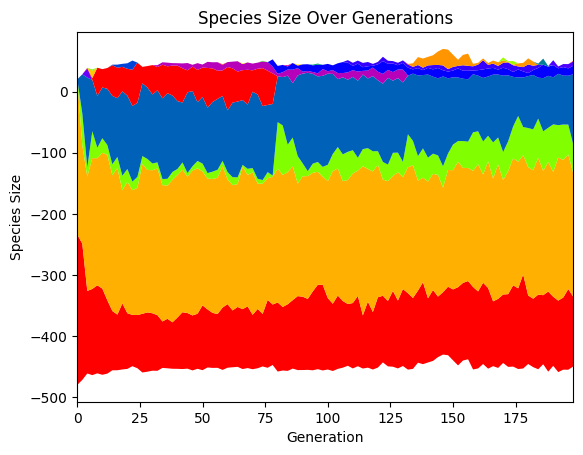

In [7]:
fig, ax = plt.subplots()
cmap = plt.get_cmap('prism')
cols = [cmap((i%50) / 50) for i in range(len(species_id_to_idx))]
ax.stackplot(generations, species_sizes_over_time.T, colors=cols, baseline='wiggle')

ax.set(xlim=(generations[0], generations[-1]))#, ylim=(0, np.max(species_sizes_over_time, axis=1)[0]))
ax.set_xlabel('Generation')
ax.set_ylabel('Species Size')
ax.set_title('Species Size Over Generations')
plt.show()

In [8]:
print(history['species']['0'][0].keys())

dict_keys(['id', 'size', 'representative', 'loss_raws', 'complexities', 'loss_insts', 'loss_finals'])


In [9]:
data_over_time = np.ones((4, 3, len(generations), len(species_id_to_idx)))*np.nan
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		for idx, name in {0:'loss_raws',1:'complexities',2:'loss_insts',3:'loss_finals'}.items():
			for jdx,fnc in {0:np.min,1:np.median,2:np.max}.items():
				arr = np.array(species[name]).astype(float)
				if np.isnan(arr).any():
					print(f"NaN found in {name} for species {species['id']} in generation {gen}")
				if np.isinf(arr).any():
					print(f"Inf found in {name} for species {species['id']} in generation {gen}")
				y = np.array(fnc([species[name]])).astype(float)
				if np.isnan(y):
					print(f"NaN found after aggregation in {name} for species {species['id']} in generation {gen}")
				elif np.isinf(y):
					print(f"Inf found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
				elif y > 1e6:
					#print(f"Unrealistically high value {y} found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
					data_over_time[idx, jdx, gi, species_idx] = np.nan
				else:
					data_over_time[idx, jdx, gi, species_idx] = y

/tmp/ipykernel_15094/2764759316.py:1: RuntimeWarning: All-NaN slice encountered
  average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])


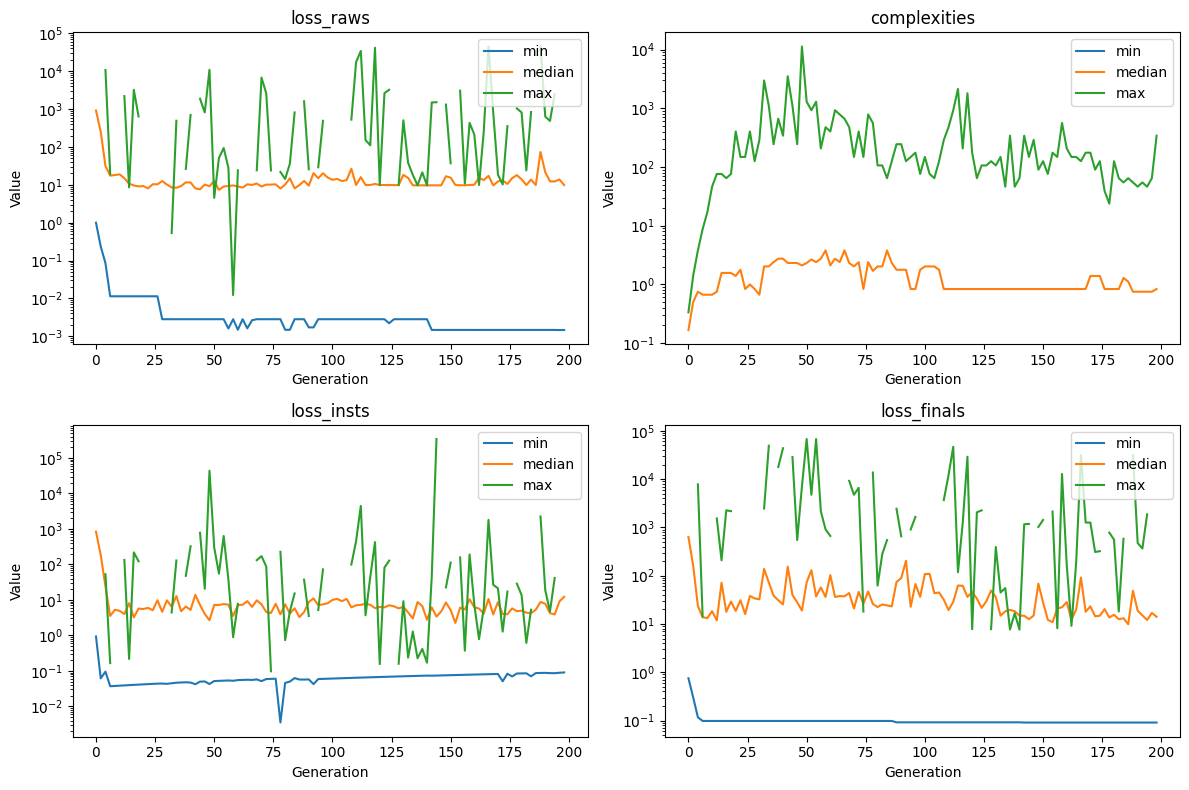

In [10]:
average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])
average_data_over_time = np.transpose(average_data_over_time, (1, 0,2))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
metric_names = ['loss_raws', 'complexities', 'loss_insts', 'loss_finals']
for idx in range(4):
	for jdx in range(3) if idx == 1 else range(3):
		ax[idx//2, idx%2].semilogy(generations, average_data_over_time[idx, jdx], label=['min', 'median', 'max'][jdx])
	ax[idx//2, idx%2].set_title(metric_names[idx])
	ax[idx//2, idx%2].set_xlabel('Generation')
	ax[idx//2, idx%2].set_ylabel('Value')
	ax[idx//2, idx%2].legend()
plt.tight_layout()
plt.show()